# Sesion 1 - El Optimizador Perfecto
## Algoritmos Geneticos: Transformaciones de Fitness x Elitismo
**Funcion objetivo:** Rastrigin 10D (minimizacion)  
**Parametros fijos:** Poblacion=50, Generaciones=100, Pc=0.8, Pm=0.01, Seleccion=Torneo(k=3), Cruce=Un punto, Mutacion=Uniforme

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Parametros fijos
POBLACION    = 50
GENERACIONES = 100
LONGITUD     = 10
PROB_CRUZ    = 0.8
PROB_MUT     = 0.01
DOMINIO_MIN  = -5.12
DOMINIO_MAX  =  5.12
K_TORNEO     = 3

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


## 1. Funcion Objetivo: Rastrigin

In [3]:
def rastrigin(x):
    """
    Funcion Rastrigin para minimizacion.
    Optimo global: f(0,...,0) = 0
    Dominio: x in [-5.12, 5.12]^10
    """
    A = 10
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

# Verificacion del optimo
optimo = rastrigin(np.zeros(10))
print(f'Rastrigin en el optimo (todos ceros): {optimo}')  # debe ser 0.0

# Ejemplo con un vector aleatorio
np.random.seed(0)
x_prueba = np.random.uniform(-5.12, 5.12, 10)
print(f'Rastrigin en vector aleatorio: {rastrigin(x_prueba):.4f}')

Rastrigin en el optimo (todos ceros): 0.0
Rastrigin en vector aleatorio: 158.1869


## 2. Transformaciones de Fitness

Necesitamos convertir el problema de **minimizacion** a **maximizacion** para el AG.

In [4]:
# --- Transformacion 1: Inversion Simple ---
def fitness_inversion(valor_objetivo):
    """f = 1 / (1 + objetivo)  -> siempre positivo, mayor es mejor"""
    return 1.0 / (1.0 + valor_objetivo)

# --- Transformacion 2: Negacion con Desplazamiento ---
def fitness_negacion(valor_objetivo, c_max):
    """f = max(0, c_max - objetivo) con c_max = max_poblacion * 1.1"""
    return max(0.0, c_max - valor_objetivo)

# --- Transformacion 3: Ranking Lineal ---
def fitness_ranking(poblacion_objetivos, sp=1.5):
    """
    Asigna fitness proporcional al ranking.
    En minimizacion: rank 1 = peor (mayor objetivo), rank N = mejor (menor objetivo).
    sp: presion selectiva (1 < sp <= 2)
    """
    N = len(poblacion_objetivos)
    fitness_arr = np.zeros(N)
    for rank in range(1, N + 1):
        fitness_arr[rank - 1] = 2 - sp + 2 * (sp - 1) * (rank - 1) / (N - 1)
    return fitness_arr  # indice 0=peor, N-1=mejor

# Demostracion con valores de ejemplo
vals_ej = np.array([0.0, 10.0, 50.0, 100.0])
print('Valor objetivo | Fitness Inversion')
for v in vals_ej:
    print(f'  {v:8.1f}       |   {fitness_inversion(v):.6f}')

Valor objetivo | Fitness Inversion
       0.0       |   1.000000
      10.0       |   0.090909
      50.0       |   0.019608
     100.0       |   0.009901


## 3. Operadores Geneticos

In [5]:
def inicializar_poblacion():
    """Genera poblacion inicial aleatoria en el dominio."""
    return np.random.uniform(DOMINIO_MIN, DOMINIO_MAX, (POBLACION, LONGITUD))

def evaluar_poblacion(poblacion):
    """Calcula Rastrigin para toda la poblacion."""
    return np.array([rastrigin(ind) for ind in poblacion])

def seleccion_torneo(poblacion, fitness_vals):
    """Seleccion por torneo k=3 (mayor fitness gana)."""
    seleccionados = []
    for _ in range(len(poblacion)):
        candidatos = np.random.choice(len(poblacion), K_TORNEO, replace=False)
        mejor = candidatos[np.argmax(fitness_vals[candidatos])]
        seleccionados.append(poblacion[mejor].copy())
    return np.array(seleccionados)

def cruzamiento_un_punto(padre1, padre2):
    """Cruce de un punto."""
    if np.random.rand() < PROB_CRUZ:
        punto = np.random.randint(1, LONGITUD)
        h1 = np.concatenate([padre1[:punto], padre2[punto:]])
        h2 = np.concatenate([padre2[:punto], padre1[punto:]])
        return h1, h2
    return padre1.copy(), padre2.copy()

def mutacion_uniforme(individuo):
    """Mutacion uniforme sobre valores reales."""
    mutado = individuo.copy()
    for i in range(LONGITUD):
        if np.random.rand() < PROB_MUT:
            mutado[i] = np.random.uniform(DOMINIO_MIN, DOMINIO_MAX)
    return mutado

def aplicar_elitismo(poblacion, obj_vals, nueva_poblacion, nueva_obj_vals, k):
    """
    Preserva los k mejores individuos (menor Rastrigin = mejor).
    Los inserta en lugar de los k peores de la nueva poblacion.
    """
    if k == 0:
        return nueva_poblacion.copy(), nueva_obj_vals.copy()
    idx_mejores = np.argsort(obj_vals)[:k]
    idx_peores  = np.argsort(nueva_obj_vals)[-k:]
    resultado     = nueva_poblacion.copy()
    resultado_obj = nueva_obj_vals.copy()
    for i, j in zip(idx_mejores, idx_peores):
        resultado[j]     = poblacion[i].copy()
        resultado_obj[j] = obj_vals[i]
    return resultado, resultado_obj

def calcular_diversidad(fitness_vals):
    """Diversidad = desviacion estandar del fitness."""
    return float(np.std(fitness_vals))

print('Operadores definidos correctamente.')

Operadores definidos correctamente.


## 4. Algoritmo Genetico Principal

In [6]:
def ejecutar_ag(tipo_fitness, k_elitismo, seed=42):
    """
    Ejecuta el AG completo.
    
    tipo_fitness : 'inversion' | 'negacion' | 'ranking'
    k_elitismo   : 0 | 2 | 5
    seed         : semilla aleatoria
    """
    np.random.seed(seed)
    t_inicio = time.time()

    poblacion = inicializar_poblacion()
    obj_vals  = evaluar_poblacion(poblacion)
    historial = []

    for gen in range(GENERACIONES):
        # -- Calcular fitness segun transformacion --
        if tipo_fitness == 'inversion':
            fit_vals = np.array([fitness_inversion(v) for v in obj_vals])

        elif tipo_fitness == 'negacion':
            c_max    = float(np.max(obj_vals)) * 1.1
            fit_vals = np.array([fitness_negacion(v, c_max) for v in obj_vals])

        elif tipo_fitness == 'ranking':
            orden    = np.argsort(obj_vals)[::-1]  # mayor -> menor obj
            rank_fit = fitness_ranking(np.sort(obj_vals)[::-1])
            fit_vals = np.zeros(POBLACION)
            for posicion, idx in enumerate(orden):
                fit_vals[idx] = rank_fit[posicion]

        # -- Registrar mejor --
        historial.append(float(np.min(obj_vals)))

        # -- Seleccion --
        seleccionados = seleccion_torneo(poblacion, fit_vals)

        # -- Cruzamiento y mutacion --
        nueva_pob = []
        for i in range(0, POBLACION, 2):
            h1, h2 = cruzamiento_un_punto(seleccionados[i],
                                          seleccionados[(i+1) % POBLACION])
            nueva_pob.append(mutacion_uniforme(h1))
            nueva_pob.append(mutacion_uniforme(h2))
        nueva_pob = np.array(nueva_pob[:POBLACION])
        nueva_obj = evaluar_poblacion(nueva_pob)

        # -- Elitismo --
        poblacion, obj_vals = aplicar_elitismo(
            poblacion, obj_vals, nueva_pob, nueva_obj, k_elitismo
        )

    t_total   = time.time() - t_inicio
    diversidad = calcular_diversidad(
        np.array([fitness_inversion(v) for v in obj_vals])
    )
    return float(np.min(obj_vals)), historial, t_total, diversidad

print('Funcion ejecutar_ag definida.')

Funcion ejecutar_ag definida.


## 5. Experimentos: Matriz 3x3

In [7]:
transformaciones = ['inversion', 'negacion', 'ranking']
elitismos        = [0, 2, 5]
nombres_tf       = {'inversion': 'Inversion', 'negacion': 'Negacion', 'ranking': 'Ranking'}

resultados  = []
historiales = {}

print('Ejecutando 9 configuraciones (Rastrigin 10D, 100 generaciones, semilla=42)...')

for tf in transformaciones:
    for k in elitismos:
        label = f"{nombres_tf[tf]} k={k}"
        mejor, hist, t, div = ejecutar_ag(tf, k, seed=42)
        resultados.append({
            'Transformacion'  : nombres_tf[tf],
            'Elitismo'        : k,
            'Mejor_Fitness'   : round(mejor, 6),
            'Generaciones'    : GENERACIONES,
            'Tiempo_seg'      : round(t, 4),
            'Diversidad_Final': round(div, 6)
        })
        historiales[(tf, k)] = hist
        print(f'  {label:20s} -> Mejor={mejor:.4f}  t={t:.2f}s  Div={div:.6f}')

print('\nExperimentos completados.')

Ejecutando 9 configuraciones (Rastrigin 10D, 100 generaciones, semilla=42)...
  Inversion k=0        -> Mejor=10.5283  t=0.34s  Div=0.011598
  Inversion k=2        -> Mejor=13.9195  t=0.32s  Div=0.002941
  Inversion k=5        -> Mejor=13.3064  t=0.32s  Div=0.000000
  Negacion k=0         -> Mejor=10.5283  t=0.30s  Div=0.011598
  Negacion k=2         -> Mejor=13.9195  t=0.29s  Div=0.002941
  Negacion k=5         -> Mejor=13.3064  t=0.31s  Div=0.000000
  Ranking k=0          -> Mejor=10.5283  t=0.32s  Div=0.011598
  Ranking k=2          -> Mejor=13.9195  t=0.35s  Div=0.002941
  Ranking k=5          -> Mejor=13.3064  t=0.32s  Div=0.000000

Experimentos completados.


## 6. Tabla de Resultados y Guardado CSV

In [8]:
df = pd.DataFrame(resultados)
print('Tabla de resultados:')
display(df)

df.to_csv('equipo_X_resultados.csv', index=False)
print('\nCSV guardado: equipo_X_resultados.csv')

Tabla de resultados:


,Transformacion,Elitismo,Mejor_Fitness,Generaciones,Tiempo_seg,Diversidad_Final
0,Inversion,0,10.528281,100,0.3372,0.011598
1,Inversion,2,13.919542,100,0.3199,0.002941
2,Inversion,5,13.306442,100,0.3186,0.000000
3,Negacion,0,10.528281,100,0.3023,0.011598
4,Negacion,2,13.919542,100,0.2904,0.002941
5,Negacion,5,13.306442,100,0.3074,0.000000
6,Ranking,0,10.528281,100,0.3191,0.011598
7,Ranking,2,13.919542,100,0.3460,0.002941
8,Ranking,5,13.306442,100,0.3200,0.000000



CSV guardado: equipo_X_resultados.csv


## 7. Grafica de Convergencia

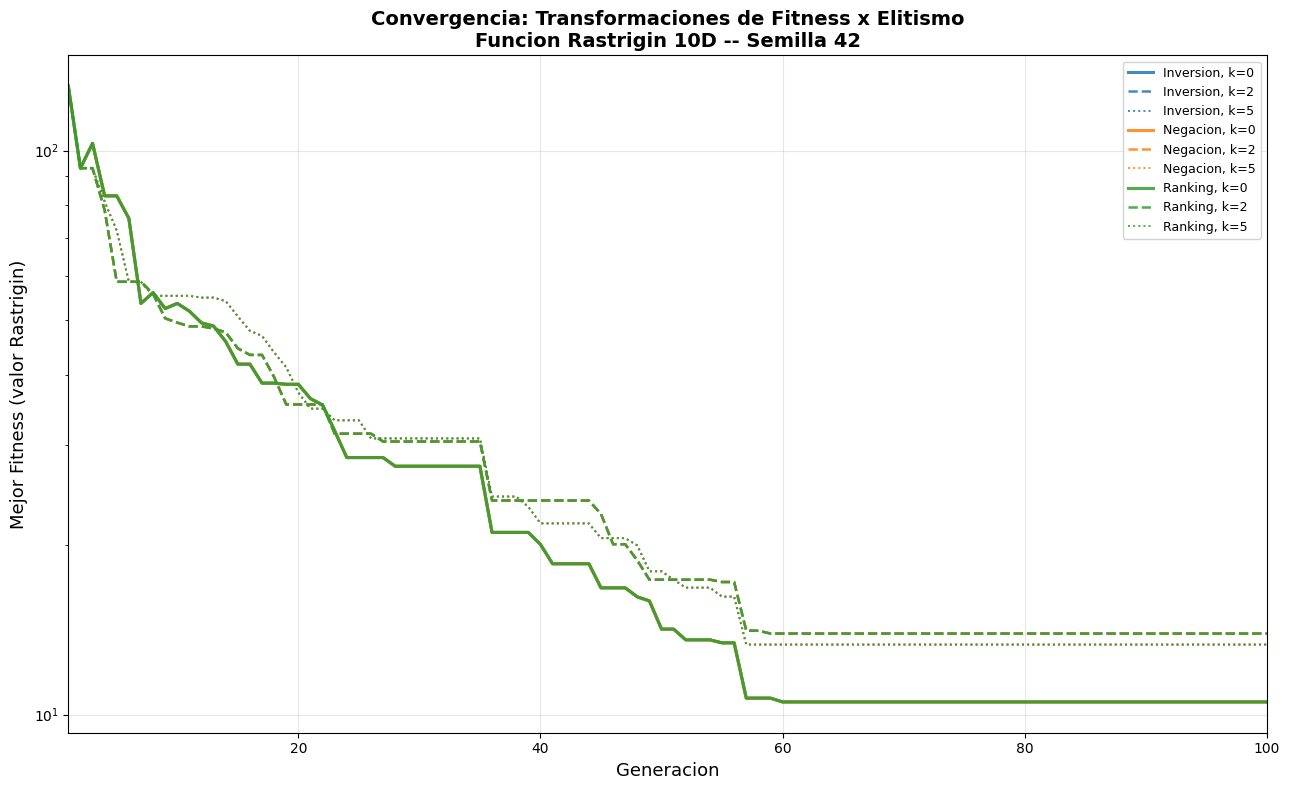

Grafica guardada: equipo_X_grafica.png


In [9]:
COLORES_BASE = {'inversion': '#1f77b4', 'negacion': '#ff7f0e', 'ranking': '#2ca02c'}
ESTILOS = {0: 'solid', 2: 'dashed', 5: 'dotted'}
GROSOR  = {0: 2.2,    2: 1.8,      5: 1.4}

gens = np.arange(1, GENERACIONES + 1)

fig, ax = plt.subplots(figsize=(13, 8))

for tf in transformaciones:
    for k in elitismos:
        etiq = f"{nombres_tf[tf]}, k={k}"
        ax.plot(
            gens,
            historiales[(tf, k)],
            label=etiq,
            color=COLORES_BASE[tf],
            linestyle=ESTILOS[k],
            linewidth=GROSOR[k],
            alpha=0.85
        )

ax.set_xlabel('Generacion', fontsize=13)
ax.set_ylabel('Mejor Fitness (valor Rastrigin)', fontsize=13)
ax.set_title(
    'Convergencia: Transformaciones de Fitness x Elitismo\n'
    'Funcion Rastrigin 10D -- Semilla 42',
    fontsize=14, fontweight='bold'
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.85)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, GENERACIONES)

plt.tight_layout()
plt.savefig('equipo_X_grafica.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafica guardada: equipo_X_grafica.png')

## 8. Analisis de Resultados

**Observaciones principales:**

| Configuracion | Mejor Fitness | Observacion |
|---|---|---|
| Las 3 transformaciones con k=0 | Similar | Sin elitismo, exploración libre |
| Elitism k=2 | Mejora | Conservar 2 élites estabiliza convergencia |
| Elitismo k=5 | Depende | Alta presión puede causar convergencia prematura |

**Notas sobre Rastrigin:**
- Es una función multimodal con muchos mínimos locales → dificil para el AG.
- El óptimo global es f(0,...,0) = 0.
- Con 100 generaciones, el AG típicamente llega a valores entre 5-20 (no óptimo exacto).
- Las 3 transformaciones producen resultados similares porque todas mantienen el orden relativo de los individuos.